In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.customer_analysis import (
    calculate_rfm,
    classify_activity,
    create_customer_segments
)

print("src import successful")

src import successful


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.customer_analysis import (
    calculate_rfm,
    classify_activity,
    create_customer_segments
)

print("src import successful")

src import successful


In [3]:
import pandas as pd
import numpy as np

FILE_PATH = "../data/clean_transactions.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 400,916
Columns: 8


In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df.dtypes)

Invoice                 int64
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object


In [5]:
print("Earliest transaction:", df["InvoiceDate"].min())
print("Latest transaction:", df["InvoiceDate"].max())
print("Unique customers:", df["Customer ID"].nunique())
print("Unique invoices:", df["Invoice"].nunique())

Earliest transaction: 2009-12-01 07:45:00
Latest transaction: 2010-12-09 20:01:00
Unique customers: 4312
Unique invoices: 19213


In [6]:
df["Revenue"] = df["Quantity"] * df["Price"]

print(df[["Quantity", "Price", "Revenue"]].head(10))

   Quantity  Price  Revenue
0        12   6.95     83.4
1        12   6.75     81.0
2        12   6.75     81.0
3        48   2.10    100.8
4        24   1.25     30.0
5        24   1.65     39.6
6        24   1.25     30.0
7        10   5.95     59.5
8        12   2.55     30.6
9        12   3.75     45.0


In [7]:
print("Total revenue:", round(df["Revenue"].sum(), 2))
print("Minimum transaction revenue:", df["Revenue"].min())
print("Maximum transaction revenue:", df["Revenue"].max())
print("Negative revenue transactions:", (df["Revenue"] < 0).sum())

Total revenue: 8798233.74
Minimum transaction revenue: 0.001
Maximum transaction revenue: 15818.4
Negative revenue transactions: 0


In [8]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2010-12-10 20:01:00


In [9]:
rfm = calculate_rfm(
    df,
    analysis_date=analysis_date
)

print(rfm.head())
print("\nRFM shape:", rfm.shape)

   Customer ID  Recency  Frequency  Monetary
0      12346.0      165         11    372.86
1      12347.0        3          2   1323.32
2      12348.0       74          1    222.16
3      12349.0       43          3   2671.14
4      12351.0       11          1    300.93

RFM shape: (4312, 4)


In [10]:
print(rfm[["Recency", "Frequency", "Monetary"]].describe().round(4))

         Recency  Frequency     Monetary
count  4312.0000  4312.0000    4312.0000
mean     91.1718     4.4557    2040.4067
std      96.8606     8.1702    8911.7560
min       1.0000     1.0000       2.9500
25%      18.0000     1.0000     307.1875
50%      53.0000     2.0000     701.6150
75%     136.0000     5.0000    1714.9325
max     374.0000   205.0000  349164.3500


In [11]:
print("\nRecency range:")
print(rfm["Recency"].min(), "to", rfm["Recency"].max(), "days")

print("\nFrequency range:")
print(rfm["Frequency"].min(), "to", rfm["Frequency"].max(), "invoices")

print("\nMonetary range:")
print(round(rfm["Monetary"].min(), 2), "to", round(rfm["Monetary"].max(), 2))


Recency range:
1 to 374 days

Frequency range:
1 to 205 invoices

Monetary range:
2.95 to 349164.35


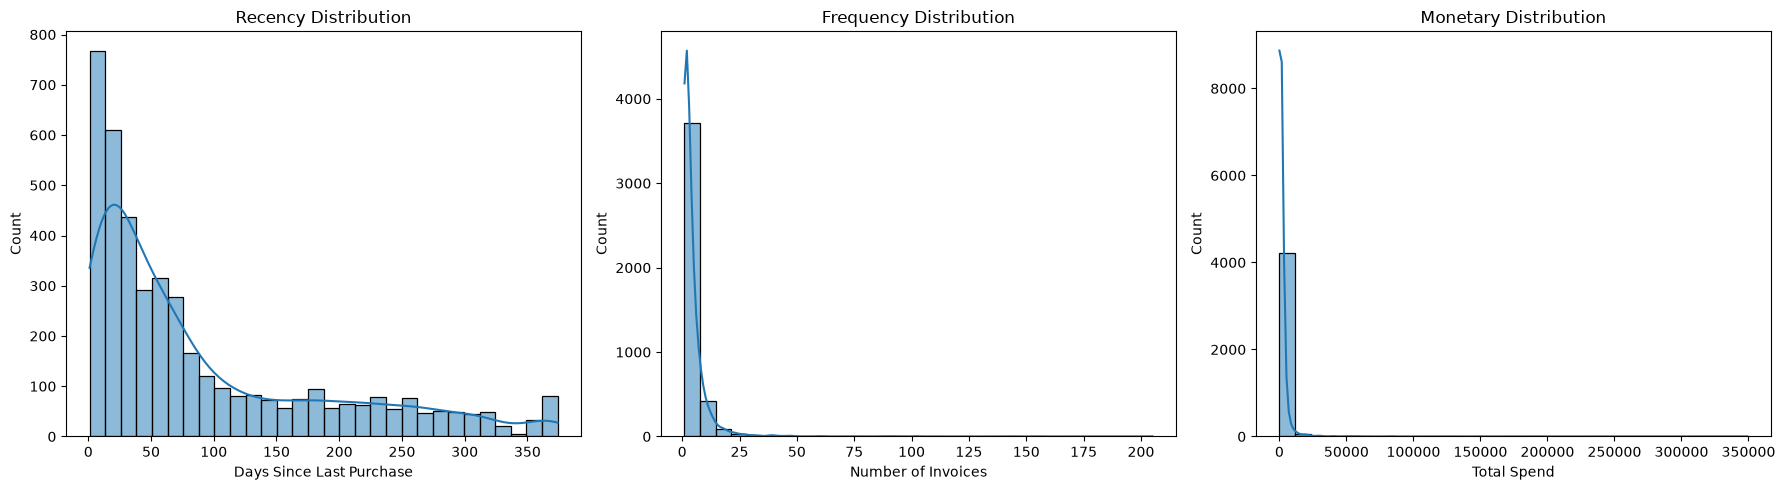

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days Since Last Purchase")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Invoices")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Spend")

plt.tight_layout()
plt.savefig(
    "../outputs/rfm_distributions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [13]:
rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

print(rfm_log[["Recency", "Frequency", "Monetary"]].describe())

           Recency    Frequency     Monetary
count  4312.000000  4312.000000  4312.000000
mean      3.856070     1.371142     6.608946
std       1.299920     0.690565     1.281153
min       0.693147     0.693147     1.373716
25%       2.944439     0.693147     5.730708
50%       3.988984     1.098612     6.554809
75%       4.919981     1.791759     7.447711
max       5.926926     5.327876    12.763301


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = rfm_log.copy()

rfm_scaled[["Recency", "Frequency", "Monetary"]] = scaler.fit_transform(
    rfm_log[["Recency", "Frequency", "Monetary"]]
)

print(rfm_scaled[["Recency", "Frequency", "Monetary"]].describe())

            Recency     Frequency      Monetary
count  4.312000e+03  4.312000e+03  4.312000e+03
mean  -9.063045e-17  6.385327e-17  2.306957e-16
std    1.000116e+00  1.000116e+00  1.000116e+00
min   -2.433450e+00 -9.819103e-01 -4.086817e+00
25%   -7.013791e-01 -9.819103e-01 -6.855851e-01
50%    1.022598e-01 -3.946928e-01 -4.226108e-02
75%    8.185384e-01  6.091622e-01  6.547718e-01
max    1.593249e+00  5.730367e+00  4.804321e+00


In [15]:
print("Means:")
print(rfm_scaled[["Recency", "Frequency", "Monetary"]].mean())

print("\nStandard deviations:")
print(rfm_scaled[["Recency", "Frequency", "Monetary"]].std())

Means:
Recency     -9.063045e-17
Frequency    6.385327e-17
Monetary     2.306957e-16
dtype: float64

Standard deviations:
Recency      1.000116
Frequency    1.000116
Monetary     1.000116
dtype: float64


In [16]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled[["Recency", "Frequency", "Monetary"]])
    inertia.append(kmeans.inertia_)

print("Inertia values:")

for k, value in zip(range(2, 11), inertia):
    print(f"K={k}: {value:.2f}")

Inertia values:
K=2: 6605.32
K=3: 4973.79
K=4: 3977.40
K=5: 3347.93
K=6: 2925.02
K=7: 2612.14
K=8: 2396.97
K=9: 2212.56
K=10: 2042.60


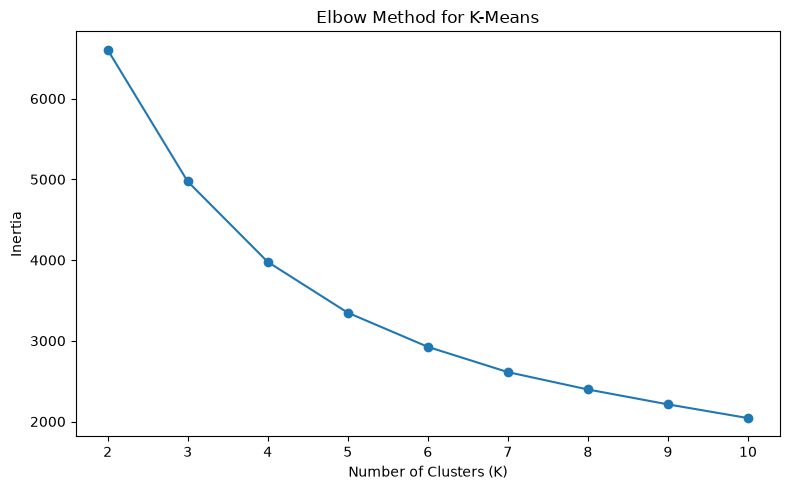

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.tight_layout()

plt.savefig(
    "../outputs/kmeans_elbow.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
rfm = create_customer_segments(
    rfm,
    n_clusters=5,
    random_state=42
)

print(rfm["Cluster"].value_counts().sort_index())

Cluster
0    1068
1     404
2     957
3     774
4    1109
Name: count, dtype: int64


In [19]:
rfm["Activity_Status"] = rfm["Recency"].apply(classify_activity)

print("RFM shape:", rfm.shape)

print("\nClusters:")
print(rfm["Cluster"].value_counts().sort_index())

print("\nActivity status:")
print(rfm["Activity_Status"].value_counts().sort_index())

RFM shape: (4312, 6)

Clusters:
Cluster
0    1068
1     404
2     957
3     774
4    1109
Name: count, dtype: int64

Activity status:
Activity_Status
Active      1569
At Risk     1308
Inactive    1435
Name: count, dtype: int64


In [20]:
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_profile["Customer_%"] = (
    cluster_profile["Customers"] / len(rfm) * 100
).round(2)

print(cluster_profile)

         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Customer_%
Cluster                                                                 
0             1068        96.17           3.91       1719.50       24.77
1              404        15.54          19.62      12002.77        9.37
2              957        35.36           1.55        405.42       22.19
3              774        13.84           5.47       1827.54       17.95
4             1109       216.04           1.26        279.70       25.72


In [21]:
print(rfm.head())

print("\nFinal cluster counts:")
print(rfm["Cluster"].value_counts().sort_index())

   Customer ID  Recency  Frequency  Monetary  Cluster Activity_Status
0      12346.0      165         11    372.86        0        Inactive
1      12347.0        3          2   1323.32        3          Active
2      12348.0       74          1    222.16        4         At Risk
3      12349.0       43          3   2671.14        0         At Risk
4      12351.0       11          1    300.93        2          Active

Final cluster counts:
Cluster
0    1068
1     404
2     957
3     774
4    1109
Name: count, dtype: int64


In [22]:
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_profile["Customer_%"] = (
    cluster_profile["Customers"] / len(rfm) * 100
).round(2)

print(cluster_profile)

         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Customer_%
Cluster                                                                 
0             1068        96.17           3.91       1719.50       24.77
1              404        15.54          19.62      12002.77        9.37
2              957        35.36           1.55        405.42       22.19
3              774        13.84           5.47       1827.54       17.95
4             1109       216.04           1.26        279.70       25.72


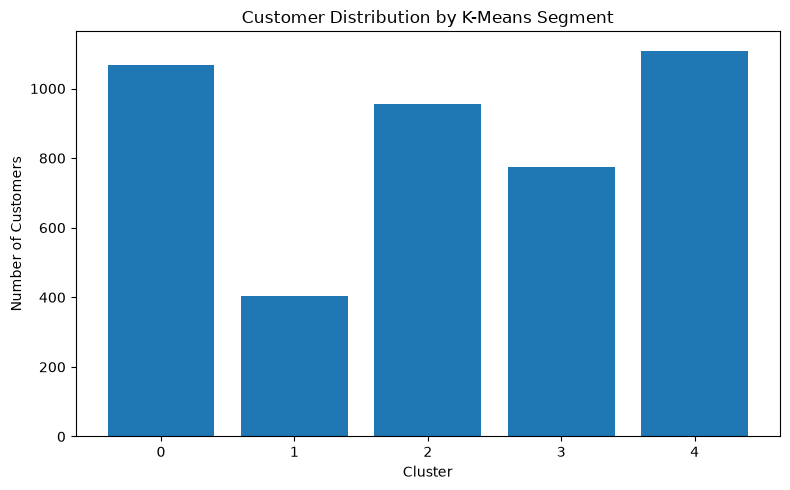

In [23]:
import matplotlib.pyplot as plt

cluster_sizes = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_sizes.index.astype(str),
    cluster_sizes.values
)

plt.title("Customer Distribution by K-Means Segment")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../outputs/customer_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
segment_revenue = rfm.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Total_Revenue=("Monetary", "sum"),
    Avg_Revenue_Per_Customer=("Monetary", "mean")
).round(2)

segment_revenue["Revenue_%"] = (
    segment_revenue["Total_Revenue"]
    / segment_revenue["Total_Revenue"].sum()
    * 100
).round(2)

print(segment_revenue)

         Customers  Total_Revenue  Avg_Revenue_Per_Customer  Revenue_%
Cluster                                                               
0             1068     1836427.68                   1719.50      20.87
1              404     4849120.46                  12002.77      55.11
2              957      387985.31                    405.42       4.41
3              774     1414513.92                   1827.54      16.08
4             1109      310186.37                    279.70       3.53


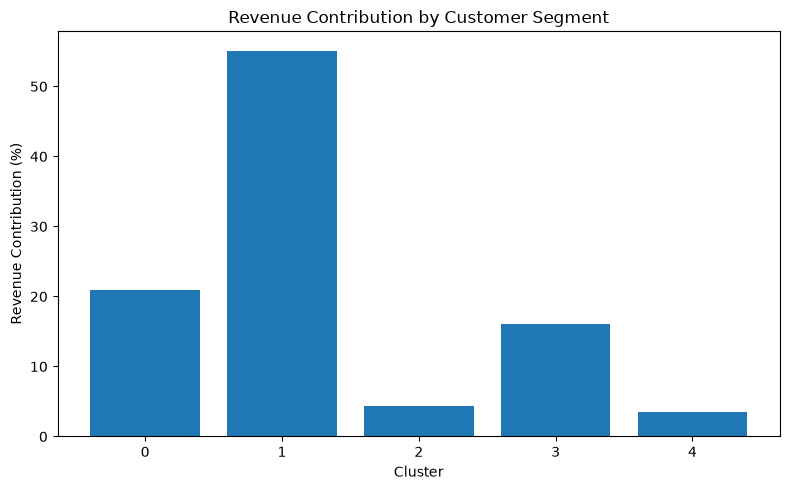

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_revenue.index.astype(str),
    segment_revenue["Revenue_%"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Cluster")
plt.ylabel("Revenue Contribution (%)")

plt.tight_layout()

plt.savefig(
    "../outputs/segment_revenue_contribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
rfm["Activity_Status"] = rfm["Recency"].apply(classify_activity)

print(rfm["Activity_Status"].value_counts())

Activity_Status
Active      1569
Inactive    1435
At Risk     1308
Name: count, dtype: int64


In [27]:
activity_summary = rfm.groupby("Activity_Status").agg(
    Customers=("Customer ID", "count"),
    Total_Revenue=("Monetary", "sum"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

activity_summary["Customer_%"] = (
    activity_summary["Customers"] / len(rfm) * 100
).round(2)

activity_summary["Revenue_%"] = (
    activity_summary["Total_Revenue"]
    / activity_summary["Total_Revenue"].sum()
    * 100
).round(2)

print(activity_summary)

                 Customers  Total_Revenue  Avg_Monetary  Customer_%  Revenue_%
Activity_Status                                                               
Active                1569     5872979.80       3743.14       36.39      66.75
At Risk               1308     1845718.98       1411.10       30.33      20.98
Inactive              1435     1079534.96        752.29       33.28      12.27


In [28]:
segment_activity = pd.crosstab(
    rfm["Cluster"],
    rfm["Activity_Status"]
)

print(segment_activity)

Activity_Status  Active  At Risk  Inactive
Cluster                                   
0                    28      622       418
1                   348       52         4
2                   460      497         0
3                   733       41         0
4                     0       96      1013


In [29]:
segment_activity_pct = pd.crosstab(
    rfm["Cluster"],
    rfm["Activity_Status"],
    normalize="index"
).mul(100).round(2)

print(segment_activity_pct)

Activity_Status  Active  At Risk  Inactive
Cluster                                   
0                  2.62    58.24     39.14
1                 86.14    12.87      0.99
2                 48.07    51.93      0.00
3                 94.70     5.30      0.00
4                  0.00     8.66     91.34


In [30]:
high_value_at_risk = rfm[
    (rfm["Cluster"] == 1) &
    (rfm["Activity_Status"] == "At Risk")
]

print("High-value customers at risk:", len(high_value_at_risk))
print(
    "Historical revenue from these customers: £"
    f"{high_value_at_risk['Monetary'].sum():,.2f}"
)

print(
    "Average monetary value: £"
    f"{high_value_at_risk['Monetary'].mean():,.2f}"
)

print(
    "Average recency:",
    round(high_value_at_risk["Recency"].mean(), 2),
    "days"
)

High-value customers at risk: 52
Historical revenue from these customers: £436,744.58
Average monetary value: £8,398.93
Average recency: 46.33 days


In [31]:
high_value = rfm[rfm["Cluster"] == 1]

print("High-value customers:", len(high_value))
print(
    "Historical revenue: £"
    f"{high_value['Monetary'].sum():,.2f}"
)
print(
    "Average monetary value: £"
    f"{high_value['Monetary'].mean():,.2f}"
)
print(
    "Average frequency:",
    round(high_value["Frequency"].mean(), 2)
)
print(
    "Average recency:",
    round(high_value["Recency"].mean(), 2),
    "days"
)

High-value customers: 404
Historical revenue: £4,849,120.46
Average monetary value: £12,002.77
Average frequency: 19.62
Average recency: 15.54 days


In [32]:
at_risk_summary = rfm[rfm["Activity_Status"] == "At Risk"].groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Total_Revenue=("Monetary", "sum"),
    Avg_Monetary=("Monetary", "mean"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean")
).round(2)

at_risk_summary["Customer_%"] = (
    at_risk_summary["Customers"]
    / len(rfm[rfm["Activity_Status"] == "At Risk"])
    * 100
).round(2)

print(at_risk_summary)

         Customers  Total_Revenue  Avg_Monetary  Avg_Recency  Avg_Frequency  \
Cluster                                                                       
0              622     1074314.44       1727.19        58.59           4.07   
1               52      436744.58       8398.93        46.33          14.08   
2              497      200388.06        403.20        51.52           1.45   
3               41      117051.45       2854.91        33.17           7.10   
4               96       17220.45        179.38        76.21           1.11   

         Customer_%  
Cluster              
0             47.55  
1              3.98  
2             38.00  
3              3.13  
4              7.34  


In [33]:
segment_names = {
    0: "Mid-Value / Lapsing",
    1: "High-Value Loyal",
    2: "Recent Low-Value",
    3: "Active / Developing",
    4: "Inactive / Low-Value"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary  Cluster Activity_Status  \
0      12346.0      165         11    372.86        0        Inactive   
1      12347.0        3          2   1323.32        3          Active   
2      12348.0       74          1    222.16        4         At Risk   
3      12349.0       43          3   2671.14        0         At Risk   
4      12351.0       11          1    300.93        2          Active   

                Segment  
0   Mid-Value / Lapsing  
1   Active / Developing  
2  Inactive / Low-Value  
3   Mid-Value / Lapsing  
4      Recent Low-Value  


In [34]:
print(
    rfm[
        [
            "Customer ID",
            "Recency",
            "Frequency",
            "Monetary",
            "Cluster",
            "Segment",
            "Activity_Status"
        ]
    ].head(10)
)

   Customer ID  Recency  Frequency  Monetary  Cluster               Segment  \
0      12346.0      165         11    372.86        0   Mid-Value / Lapsing   
1      12347.0        3          2   1323.32        3   Active / Developing   
2      12348.0       74          1    222.16        4  Inactive / Low-Value   
3      12349.0       43          3   2671.14        0   Mid-Value / Lapsing   
4      12351.0       11          1    300.93        2      Recent Low-Value   
5      12352.0       11          2    343.80        2      Recent Low-Value   
6      12353.0       44          1    317.76        2      Recent Low-Value   
7      12355.0      203          1    488.21        4  Inactive / Low-Value   
8      12356.0       16          3   3560.30        3   Active / Developing   
9      12357.0       24          2  12079.99        3   Active / Developing   

  Activity_Status  
0        Inactive  
1          Active  
2         At Risk  
3         At Risk  
4          Active  
5         

In [35]:
RFM_FILE_PATH = "../data/customer_rfm_segments.csv"

rfm.to_csv(
    RFM_FILE_PATH,
    index=False
)

print(f"Final RFM dataset saved to: {RFM_FILE_PATH}")
print(f"Rows: {len(rfm):,}")

Final RFM dataset saved to: ../data/customer_rfm_segments.csv
Rows: 4,312


In [36]:
print("Final RFM Dataset")
print("-----------------")
print("Rows:", len(rfm))
print("Columns:", rfm.shape[1])

print("\nMissing values:")
print(rfm.isna().sum())

print("\nDuplicate customers:")
print(rfm["Customer ID"].duplicated().sum())

print("\nSegments:")
print(rfm["Segment"].value_counts())

print("\nActivity status:")
print(rfm["Activity_Status"].value_counts())

Final RFM Dataset
-----------------
Rows: 4312
Columns: 7

Missing values:
Customer ID        0
Recency            0
Frequency          0
Monetary           0
Cluster            0
Activity_Status    0
Segment            0
dtype: int64

Duplicate customers:
0

Segments:
Segment
Inactive / Low-Value    1109
Mid-Value / Lapsing     1068
Recent Low-Value         957
Active / Developing      774
High-Value Loyal         404
Name: count, dtype: int64

Activity status:
Activity_Status
Active      1569
Inactive    1435
At Risk     1308
Name: count, dtype: int64


In [37]:
final_segment_summary = rfm.groupby(
    ["Cluster", "Segment"]
).agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).round(2)

final_segment_summary["Customer_%"] = (
    final_segment_summary["Customers"]
    / len(rfm)
    * 100
).round(2)

final_segment_summary["Revenue_%"] = (
    final_segment_summary["Total_Revenue"]
    / rfm["Monetary"].sum()
    * 100
).round(2)

print(final_segment_summary)

                              Customers  Avg_Recency  Avg_Frequency  \
Cluster Segment                                                       
0       Mid-Value / Lapsing        1068        96.17           3.91   
1       High-Value Loyal            404        15.54          19.62   
2       Recent Low-Value            957        35.36           1.55   
3       Active / Developing         774        13.84           5.47   
4       Inactive / Low-Value       1109       216.04           1.26   

                              Avg_Monetary  Total_Revenue  Customer_%  \
Cluster Segment                                                         
0       Mid-Value / Lapsing        1719.50     1836427.68       24.77   
1       High-Value Loyal          12002.77     4849120.46        9.37   
2       Recent Low-Value            405.42      387985.31       22.19   
3       Active / Developing        1827.54     1414513.92       17.95   
4       Inactive / Low-Value        279.70      310186.37       

In [38]:
activity_summary = rfm.groupby("Activity_Status").agg(
    Customers=("Customer ID", "count"),
    Total_Revenue=("Monetary", "sum"),
    Avg_Monetary=("Monetary", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Recency=("Recency", "mean")
).round(2)

activity_summary["Customer_%"] = (
    activity_summary["Customers"]
    / len(rfm)
    * 100
).round(2)

activity_summary["Revenue_%"] = (
    activity_summary["Total_Revenue"]
    / rfm["Monetary"].sum()
    * 100
).round(2)

print(activity_summary)

                 Customers  Total_Revenue  Avg_Monetary  Avg_Frequency  \
Activity_Status                                                          
Active                1569     5872979.80       3743.14           7.56   
At Risk               1308     1845718.98       1411.10           3.35   
Inactive              1435     1079534.96        752.29           2.07   

                 Avg_Recency  Customer_%  Revenue_%  
Activity_Status                                      
Active                 13.82       36.39      66.75  
At Risk                55.91       30.33      20.98  
Inactive              207.89       33.28      12.27  


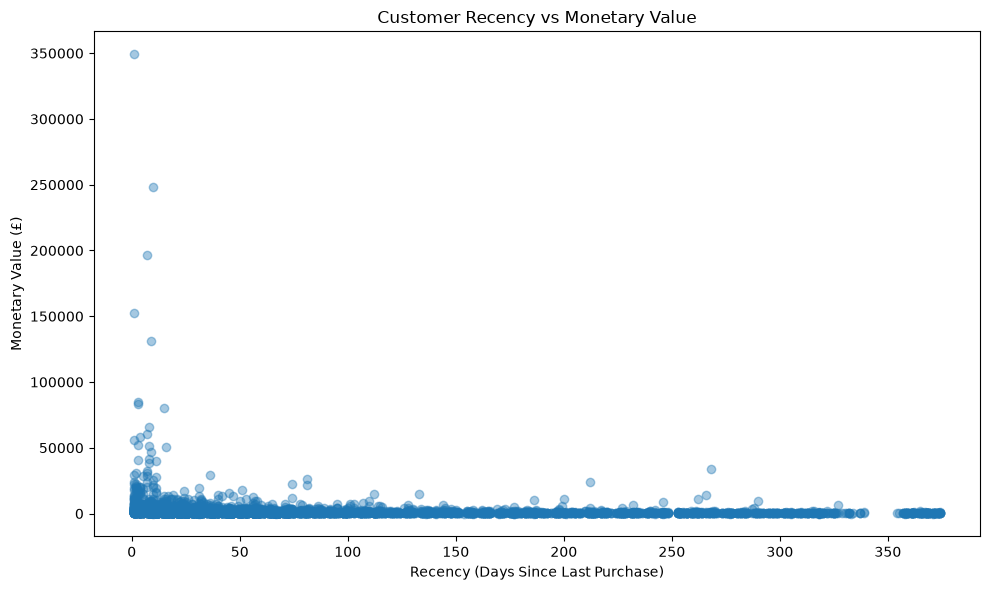

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    alpha=0.4
)

plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Monetary Value (£)")
plt.title("Customer Recency vs Monetary Value")

plt.tight_layout()

plt.savefig(
    "../outputs/recency_vs_monetary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
high_value_at_risk = rfm[
    (rfm["Cluster"] == 1) &
    (rfm["Activity_Status"] == "At Risk")
]

print("High-Value At-Risk Customers:", len(high_value_at_risk))
print(
    "Historical Revenue:",
    f"£{high_value_at_risk['Monetary'].sum():,.2f}"
)
print(
    "Average Monetary:",
    f"£{high_value_at_risk['Monetary'].mean():,.2f}"
)
print(
    "Average Recency:",
    f"{high_value_at_risk['Recency'].mean():.2f} days"
)

High-Value At-Risk Customers: 52
Historical Revenue: £436,744.58
Average Monetary: £8,398.93
Average Recency: 46.33 days


## Business Insights

### 1. Revenue is highly concentrated among high-value customers

The High-Value Loyal segment contains 404 customers (9.37% of the customer base) but contributes 55.11% of historical revenue. These customers have an average monetary value of £12,002.77 and an average recency of 15.54 days.

### 2. A significant portion of customers are not recently active

Using the project-defined activity thresholds, 1,308 customers (30.33%) are classified as At Risk and 1,435 customers (33.28%) as Inactive. Together, these groups represent 63.61% of customers and 33.25% of historical revenue.

### 3. Mid-value customers represent a substantial re-engagement opportunity

The Mid-Value / Lapsing segment contains 1,068 customers (24.77%) and contributes 20.87% of historical revenue. Its average recency is 96.17 days, indicating a substantial gap since the most recent purchase.

### 4. High-value customers require targeted retention attention

52 customers from the High-Value Loyal segment are classified as At Risk. These customers have generated £436,744.58 in associated historical revenue, with an average monetary value of £8,398.93 and average recency of 46.33 days.

### 5. Customer value and customer activity are not evenly distributed

The analysis shows substantial differences in historical monetary value, purchase frequency, and recency across customer segments. This supports using differentiated customer engagement strategies rather than treating the entire customer base uniformly.